### Google Capstone - Model building and Evaluation

##### Scenario

You are a data professional working for Salifort Motors. Currently, there is a high rate of turnover among Salifort employees. (Note: In this context, turnover data includes both employees who choose to quit their job and employees who are let go). Salifort’s senior leadership team is concerned about how many employees are leaving the company. Salifort strives to create a corporate culture that supports employee success and professional development. Further, the high turnover rate is costly in the financial sense. Salifort makes a big investment in recruiting, training, and upskilling its employees. 

If Salifort could predict whether an employee will leave the company, and discover the reasons behind their departure, they could better understand the problem and develop a solution. 

As a first step, the leadership team asks Human Resources to survey a sample of employees to learn more about what might be driving turnover.  

Next, the leadership team asks you to analyze the survey data and come up with ideas for how to increase employee retention. To help with this, they suggest you design a model that predicts whether an employee will leave the company based on their job title, department, number of projects, average monthly hours, and any other relevant data points. A good model will help the company increase retention and job satisfaction for current employees, and save money and time training new employees. 

As a specialist in data analysis, the leadership team leaves it up to you to choose an approach for building the most effective model to predict employee departure.

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time
import pickle
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

# Import data
df = pd.read_csv("preproccessed_data_Google_capstone.csv")

In [3]:
# View how many columns and rows of data and the first 3 rows.
print(f"Rows {df.shape[0]}, Columns: {df.shape[1]}")
df.head(3)

Rows 11991, Columns: 21


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,left,promotion_last_5years,high,low,...,IT,RandD,accounting,hr,management,marketing,product_mng,sales,support,technical
0,0.38,0.53,0.0,0.285047,0.125,0,1,0,0,1,...,0,0,0,0,0,0,0,1,0,0
1,0.80,0.86,0.6,0.775701,0.500,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0.11,0.88,1.0,0.822430,0.250,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0


Splitting the data into training, testing and validation sets.

In [3]:
# Split that dataset into the features and the predicted feature.
x = df.drop("left", axis=1)

y = df["left"]

# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# Take half of the test set to be the validation set to give a 70%, 15%, 15% split for training, test and validation.
print(f"Half of test set: {len(y_test)/2:.0f}")

# Half of the test set is now the validation set
x_valid = x_test.iloc[:1799]
y_valid = y_test.iloc[:1799]

# The remainder is the test set
x_test = x_test.iloc[1799:]
y_test = y_test.iloc[1799:]
print(f"Test set: {len(y_test)}")
print(f"Validation set: {len(y_valid)}")

Half of test set: 1799
Test set: 1799
Validation set: 1799


##### Classification Models

Firatly the Naive bayes classifier will be used, to act as a baseline for comparison to other models and ensemble classifiers.


In [4]:
# Initialise the Gaussian Naive Bayes classifier
nb = GaussianNB()

# Train the model
nb.fit(x_train, y_train)

# Predict the labels for the test and training sets
y_train_pred = nb.predict(x_train)
y_pred = nb.predict(x_test)


# Calculate the accuracy
nb_train_accuracy = accuracy_score(y_train, y_train_pred)
nb_test_accuracy = accuracy_score(y_test, y_pred)
print(f"Naive Bayes classifier train accuracy: {nb_train_accuracy*100:.2f}%")
print(f"Naive Bayes classifier test accuracy: {nb_test_accuracy*100:.2f}%")

Naive Bayes classifier train accuracy: 76.13%
Naive Bayes classifier test accuracy: 77.32%


#### Comparison with other single learner models

Table of models with their accuracy scores:

| Model | Train Accuracy | Test Accuracy |
| --- | :-: | :-: |
| Naive Bayes | 76.13% | 77.32% |
| Decision tree | **98.49%** | **98.55%** |
| Logistic regression | 84.11% | 82.38% |
| Support Vector Machine | 95.77% | 96% |

The decision tree performed best, closely followed by the support vector machine.

In [5]:
# Decision tree with a grid search to tune hyperpararaters with 5-fold cross validation
# Initialise Decision Tree Classifier
tree = DecisionTreeClassifier(random_state=42) 

# Create paramaters grid to search through, search it and train the model with the best hyperparamaters
start = time.time() # Timing the grid search
param_grid = {'max_depth': [1, 2, 3, 4, 5, 6, 8, 10], 'min_samples_leaf': [1, 2, 3, 4, 5, 8, 10, 15, 20],
    'min_samples_split': [2, 3, 4, 5, 8, 10, 15, 20], 'criterion': ["entropy", "gini"]}
grid_search = GridSearchCV(estimator=tree, param_grid=param_grid, verbose=True)
grid_search.fit(x_train, y_train)
end = time.time()
print(f"Best paramaters found in {end - start:.2f} seconds.", end="\n\n")

dec_tree_acc = grid_search.best_score_
print(f"Decision tree accuracy: {dec_tree_acc*100:.2f}%")
print("Best parameters:", grid_search.best_params_, end="\n\n")

# Make predictions with the test data.
y_test_pred = grid_search.predict(x_test) 
test_acc  = accuracy_score(y_test, y_test_pred)
print(f"Test accuracy: {test_acc*100:.2f}%")

Fitting 5 folds for each of 1152 candidates, totalling 5760 fits
Best paramaters found in 89.35 seconds.

Decision tree accuracy: 98.49%
Best parameters: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 20}

Test accuracy: 98.55%


In [6]:
# Binary Logistic Regression
# Initialise Logistic Regression Classifier
log_reg = LogisticRegression(max_iter=1000, random_state=42) # Max_iter=1000 to supress potential convergance warnings.

# Create paramaters grid to search through, search it and train the model with the best hyperparamaters
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100], # Different values with logarithmic steps.
    'solver': ['lbfgs', 'liblinear', 'newton-cholesky']} # Default, plus two binary suited algorithms.

start = time.time() # Timing the grid search
grid_search_lr = GridSearchCV(log_reg, param_grid, scoring='accuracy', n_jobs=-1, verbose=True)
grid_search_lr.fit(x_train, y_train)
end = time.time()
print(f"Best paramaters found in {end - start:.2f} seconds.", end="\n\n")

log_reg_acc = grid_search_lr.best_score_
print(f"Logistic regression accuracy: {log_reg_acc*100:.2f}%")
print("Best parameters:", grid_search_lr.best_params_, end="\n\n")

# Make predictions with the test data.
y_test_pred = grid_search_lr.predict(x_test) 
test_acc  = accuracy_score(y_test, y_test_pred)
print(f"Test accuracy: {test_acc*100:.2f}%")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best paramaters found in 6.35 seconds.

Logistic regression accuracy: 84.11%
Best parameters: {'C': 0.1, 'solver': 'newton-cholesky'}

Test accuracy: 82.38%


In [7]:
# Support Vector Machine
# Initialise Support Vector Machine
svc = SVC(random_state=42)

# Create paramaters grid to search through, search it and train the model with the best hyperparamaters
param_grid = {'C': [0.1, 1, 10, 100], 'kernel': ['rbf', 'linear'], 'gamma': ['scale', 0.001, 0.01, 0.1]}

start = time.time() # Timing the grid search
grid_search_svc = GridSearchCV(svc, param_grid, scoring='accuracy', n_jobs=-1, verbose=True)
grid_search_svc.fit(x_train, y_train)
end = time.time()
print(f"Best paramaters found in {end - start:.2f} seconds.", end="\n\n")

svc_acc = grid_search_svc.best_score_
print(f"Logistic regression accuracy: {svc_acc*100:.2f}%")
print("Best parameters:", grid_search_svc.best_params_, end="\n\n")

# Make predictions with the test data.
y_test_pred = grid_search_svc.predict(x_test) 
test_acc  = accuracy_score(y_test, y_test_pred)
print(f"Test accuracy: {test_acc*100:.2f}%")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best paramaters found in 434.04 seconds.

Logistic regression accuracy: 95.77%
Best parameters: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}

Test accuracy: 96.00%


#### Ensemble Methods: Bagging and Boosting & Stacking

The three main ensemble methods are desribed briefly below:

**Bagging:** A homogenous set of base learners, typically decision trees, that are trained independently. These leaners then vote or average their predictions.

Data used - Random sampling with replacement 

Advantage - Reduces variance and overfitting to stabilise the model.

Models - Random Forest, Balanced Random Forest, Rotation Forest

**Boosting:**  A homogenous sequence of learners, with each sequential leaner gving a higher weight to the mistakes made by the previous learner. Focusing on the incorrect predictions aims to ensure these are corrected in subsequent learners. A weighted average of these leaners predecitions is used when making predictions.

Advantage - Reduces bias, so will be unlikely to underfit the data.

Models - Gradient Boosting, AdaBoost, XGBoost, LightGBM, CatBoost

**Stacking:** A mix of several different types of base learners. These learners give output predictions that in turn become features for a meta-learner. This is typically a simpler model such as logistic regression. This model will use these predctions to judge the stregths of each leaner in paricular areas of the data.

Data used - All data is used on each of the base learners in the ensemble.

Advantage - Reduces bias and variance.

**Methods used:**

As the decision tree gave the best performance, a random forest will be the first ensemble method chosen. Random forest is a bagging methodology, so for comparison the boosting methods Adaboost and XGboost will be used, to give a wider range of techniques.


In [8]:
# Random Forest
# Initialise Random Forest Classifier
rf = RandomForestClassifier(random_state=42, n_jobs=-1)   # n_jobs=-1 uses all CPU cores for faster training

# Create parameter grid to search through, search it and train the model with the best hyperparameters
start = time.time()  # Timing the grid search

param_grid = {'n_estimators': [100, 200, 300, 500], 'max_depth': [10, 20],
              'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2], 'criterion': ['gini', 'entropy']}

grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid, verbose=True, n_jobs=-1)
grid_search_rf.fit(x_train, y_train)
end = time.time()
print(f"Best parameters found in {end - start:.2f} seconds.", end="\n\n")

rf_best_acc = grid_search_rf.best_score_
print(f"Random Forest Best CV Accuracy: {rf_best_acc*100:.2f}%")
print("Best parameters:", grid_search_rf.best_params_, end="\n\n")

# Make predictions with the test data
y_test_pred = grid_search_rf.predict(x_test)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_acc*100:.2f}%")

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best parameters found in 76.10 seconds.

Random Forest Best CV Accuracy: 98.40%
Best parameters: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 500}

Test Accuracy: 98.17%


In [12]:
# AdaBoost
# Initialise AdaBoost Classifier
ada = AdaBoostClassifier(random_state=42)

# Create parameter grid to search through, search it and train the model with the best hyperparameters
start = time.time()  # Timing the grid search
param_grid = {'n_estimators': [50, 100, 200, 300], 'learning_rate': [0.01, 0.1, 0.5, 1.0]}
grid_search = GridSearchCV(estimator=ada, param_grid=param_grid, verbose=True, n_jobs=-1)
grid_search.fit(x_train, y_train)
end = time.time()
print(f"Best parameters found in {end - start:.2f} seconds.", end="\n\n")

ada_best_acc = grid_search.best_score_
print(f"AdaBoost Best CV Accuracy: {ada_best_acc*100:.2f}%")
print("Best parameters:", grid_search.best_params_, end="\n\n")

# Make predictions with the test data
y_test_pred = grid_search.predict(x_test)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_acc*100:.2f}%")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters found in 17.15 seconds.

AdaBoost Best CV Accuracy: 96.31%
Best parameters: {'learning_rate': 1.0, 'n_estimators': 300}

Test Accuracy: 96.78%


In [13]:
# XGBoost
# Initialise XGBoost Classifier
xgb = XGBClassifier(random_state=42, n_jobs=-1)   # n_jobs=-1 uses all CPU cores for faster training

# Create parameter grid to search through, search it and train the model with the best hyperparameters
start = time.time()  # Timing the grid search

param_grid = {'n_estimators': [100, 200, 300, 500], 'max_depth': [3, 5, 7, 10], 'learning_rate': [0.01, 0.1, 0.2, 0.3],
              'subsample': [0.8, 1.0], 'colsample_bytree': [0.8, 1.0]}

grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, verbose=True, n_jobs=-1)
grid_search.fit(x_train, y_train)
end = time.time()
print(f"Best parameters found in {end - start:.2f} seconds.", end="\n\n")

xgb_best_acc = grid_search.best_score_
print(f"XGBoost Best CV Accuracy: {xgb_best_acc*100:.2f}%")
print("Best parameters:", grid_search.best_params_, end="\n\n")

# Make predictions with the test data
y_test_pred = grid_search.predict(x_test)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Make predictions with the test data
y_valid_pred = grid_search.predict(x_valid)
test_acc = accuracy_score(y_valid, y_valid_pred)
print(f"Validation Accuracy: {test_acc*100:.2f}%")

Fitting 5 folds for each of 256 candidates, totalling 1280 fits
Best parameters found in 78.57 seconds.

XGBoost Best CV Accuracy: 98.45%
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 10, 'n_estimators': 200, 'subsample': 1.0}

Test Accuracy: 98.28%
Validation Accuracy: 97.89%


#### Saving the model

In [14]:
# Save the XGBoost model
with open("XGBoost_model.pkl", "wb") as file:
    pickle.dump(grid_search.best_estimator_, file)

print("Model saved as XGboost_model.pkl")

Model saved as XGboost_model.pkl


In [15]:
# Load the mode
with open("XGboost_model.pkl", "rb") as file:
    XGboost_model = pickle.load(file)

print("XGboost model loaded")

XGboost model loaded


#### Evaluation of results

The test accuaracy for Random Forest and XGBoost were virtually the same, 98.40% vs 98.45%. There is not much between the two models, but for future speed benefits at scale I will be analysing the XGBoost model.

Table of models with their accuracy scores:

| Model | Train Accuracy | Test Accuracy |
| --- | :-: | :-: |
| Random Forest | 98.40% | 98.17% |
| AdaBoost| 96.31% | 96.78% |
| XGBoost | **98.45%** | **98.28%** |

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1508
           1       0.98      0.89      0.93       291

    accuracy                           0.98      1799
   macro avg       0.98      0.94      0.96      1799
weighted avg       0.98      0.98      0.98      1799




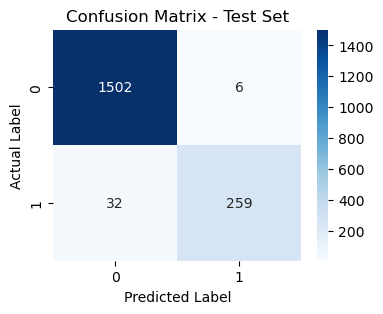

In [16]:
# Create Classification Report
print("Classification Report:")
print(classification_report(y_valid, y_valid_pred), end="\n\n")

# Confusion Matrix as a Heatmap
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_valid, y_valid_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

#### Summary of model results and potential improvements.

The confusion matrix reveals the strengths and one slight weakness of the model. Overall, the model is very strong with the vast majority of predictions made correctly. The slight weakness in the model is shown by the 32 false negatives. This is where people were predicted to have stayed when they actually left. This shows a slight bias towards predicting people to stay at the company. This in unsuprising in an unbalanced dataset, which has 83% to 17% class imbalance.

The two classes were 0 (stayed and 1 (left). The F1-score for the model was high at 0.99 for the 0 class, with both preciosn and recall being high with only three misclassifications of 0 labels.

For the left class, the F1-score was not as high at 0.93, due to the recall of 0.89. This was caused by the above described weakness in the model, causing 11% of the people that left to be incorrectly predicteed to have stayed.

A potential improvemnet to the mode to rectify this would be to use synthetic data by oversampling the minority class to better balance the model. The model worked well however, with close to 98% accuracy at the test and validation stages, and has revealed several insights that could be used to improve employee retention.

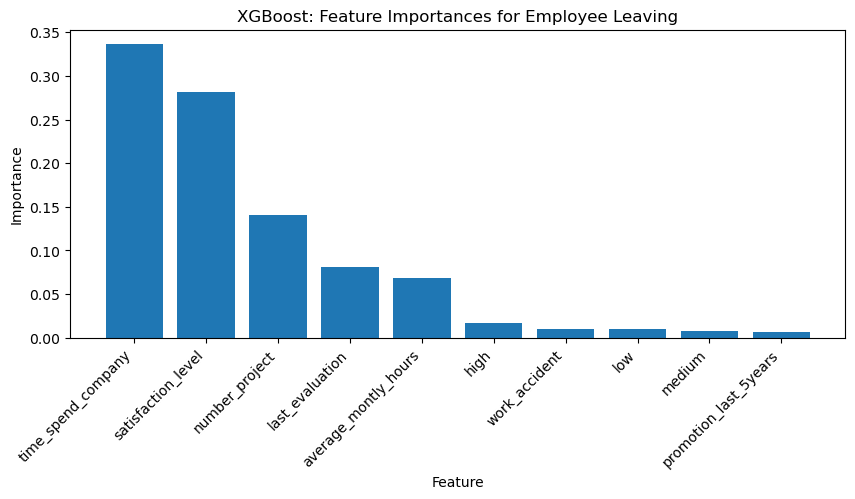

In [17]:
# View importance of features as a sorted list from highest to lowest.
sorted_list = sorted(zip(grid_search.best_estimator_.feature_names_in_, grid_search.best_estimator_.feature_importances_), key=lambda x: x[1], reverse=True)[:10]
sorted_dict = dict(sorted_list) # Convert to dictionary for readability

# View feature importance as a bar graph.
plt.figure(figsize=(10,4))
plt.bar(sorted_dict.keys(), sorted_dict.values())
plt.title("XGBoost: Feature Importances for Employee Leaving")
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha="right") # x lables at 45 degree angle with right horizontal alignment
plt.show()

The feature importances indicate that time_spend_company and satisfaction level were the two most important features, then number of projects, last evaluation score and average monthly hours. This does correlate with the EDA, as there were very few employees who left after working for the company for 5 years.

After these strong top five features, a high wage is the next greatest predictor, which also agrees with the EDA conclusion that people with a higher wage are statistically less likely to leave the comapany.

To drill deeper into how important each feature is in predicting whether an employee will leave the company I will run a permutation importance test. This shows how important each feature is by running the model with each feature essentially exluded in turn.

In [34]:
# Run permutation importances
result = permutation_importance(XGboost_model, x_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Dispaly top six results, sorted by descending importance mean values.
perm_imp = pd.DataFrame({"Feature": x_test.columns, "Importance Mean": result.importances_mean, "Importance Std": result.importances_std}).sort_values("Importance Mean", ascending=False)
perm_imp = perm_imp.reset_index(drop=True)
perm_imp.head(6)

,Feature,Importance Mean,Importance Std
0,satisfaction_level,0.152918,0.003458
1,number_project,0.090384,0.002668
2,last_evaluation,0.086715,0.003516
3,average_montly_hours,0.082212,0.003458
4,time_spend_company,0.068594,0.002451
5,accounting,0.000000,0.000000


After running this we can see that the most important feature in predicting if an employee leaves is their satisfaction level. After this the number of projects, last evaluationa dn average monthly hours are most important. This makes intuitive sense, as employees who have two many projects, or work too many hours can suffer from burnout.

Lastly I will run the SHAP method, to see how the features directly contribute, and in which direction, to the prediction.

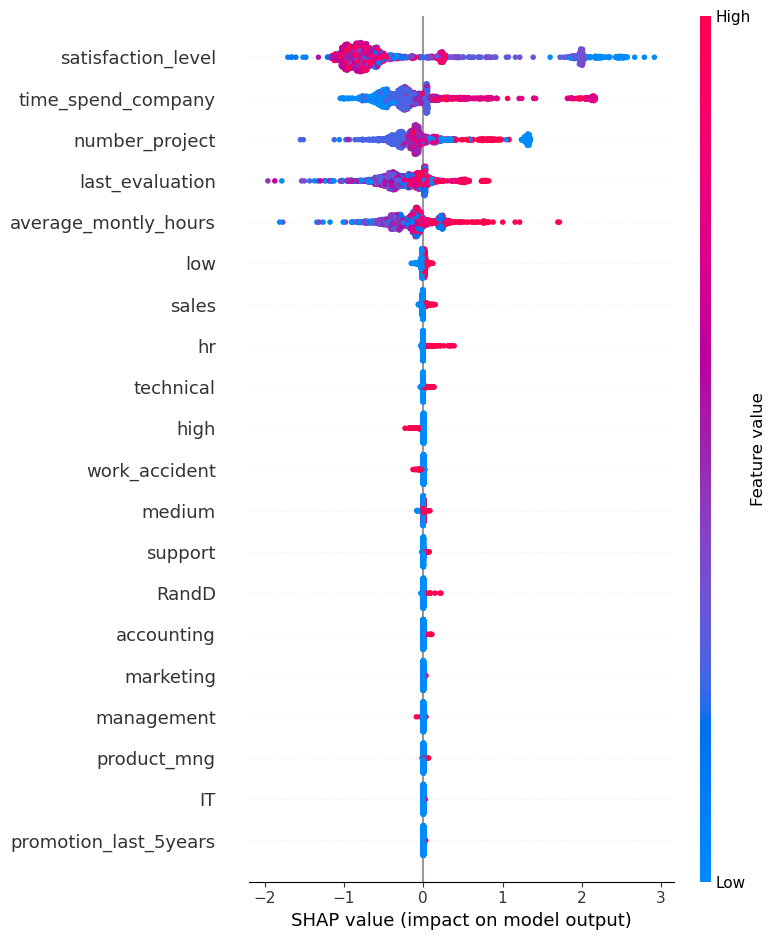

In [36]:
# Shapley Additive explanations Summary Plot
shap.summary_plot(shap.TreeExplainer(XGboost_model).shap_values(x_test), x_test)

#### SHAP Evaluation
Satisfaction level is very much the dominant feature, with the cluster of pink dots indicating a high value, which pushes the prediction towards less chance of leaving.

Time spent at company is second, with the low values trending towards the left (staying) and the smaller number of higher values pushing the prediction towards the the employee leaving, but not in as a significant way as low satisfaction scores do.

The number of projects is more of a mixed bag, with interestingly a cluster of low values on the left the company side. This indicates that while it is a predictive value, there is a cluster of people that have a low number of projects, but also left the company.

#### Insights and business recommendations

To retain employees, I would make the following recommendations, based on the model results and EDA.

Cap the number of projects an employee is working on a one time, to prevent burn out.

Cap the number of overtime hours an employee is allowed to do, unless a special exception is made. The long hours do not help with employee satisfaction, so ensure employees are fairly rewarded for working them if absolutely necessary.

#### Future Work

Predicting satisfaction score instead of whether an employee left could also be useful, as a binary choice such as an employee leaving can happen for many reasons, whereas their overall satisfaction score is a more direct reflection of how they are feeling. This feeling can be biased depending on their mood at the time, how they rank their satisfaction compared to other employees, and other factors, so is also an imperfect measure.